In [1]:
!pip install timm thop

# **Imports**

In [2]:
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

In [3]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# **Device**

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Image Preprocessing**

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# **Load Dataset**

In [6]:
data_path = "/kaggle/input/datasets/adithyadiwamjee/train-data/train_data"

dataset = ImageFolder(data_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32)

# **Load DenseNet121**

In [7]:
model = timm.create_model("densenet121", pretrained=True)

model.reset_classifier(30)

model = model.to(device)

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

# **Linear Probe (Freeze Backbone)**

In [8]:
for param in model.parameters():
    param.requires_grad = False

for param in model.get_classifier().parameters():
    param.requires_grad = True

# **Optimizer + Loss**

In [9]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# **Training Function**

In [10]:
def train_model(model, train_loader, val_loader, epochs=15):

    train_acc_list = []
    val_acc_list = []
    train_loss_list = []

    for epoch in range(epochs):

        model.train()

        correct = 0
        total = 0
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss_list.append(running_loss/len(train_loader))

        train_acc = correct/total
        train_acc_list.append(train_acc)

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct/total
        val_acc_list.append(val_acc)
        print(f"Epoch {epoch+1}: Train={train_acc:.3f}, Val={val_acc:.3f}")

    return train_acc_list, val_acc_list, train_loss_list

# **Train Model**

In [11]:
train_acc, val_acc, train_loss_list = train_model(model,train_loader,val_loader,epochs=15)

Epoch 1: Train=0.614, Val=0.787
Epoch 2: Train=0.852, Val=0.846
Epoch 3: Train=0.889, Val=0.858
Epoch 4: Train=0.909, Val=0.868
Epoch 5: Train=0.928, Val=0.874
Epoch 6: Train=0.936, Val=0.880
Epoch 7: Train=0.949, Val=0.881
Epoch 8: Train=0.953, Val=0.887
Epoch 9: Train=0.959, Val=0.889
Epoch 10: Train=0.960, Val=0.896
Epoch 11: Train=0.969, Val=0.888
Epoch 12: Train=0.970, Val=0.895
Epoch 13: Train=0.974, Val=0.891
Epoch 14: Train=0.978, Val=0.895
Epoch 15: Train=0.980, Val=0.897


In [12]:
torch.save(model.state_dict(), "densenet_100.pth")

# **Accuracy Plot**

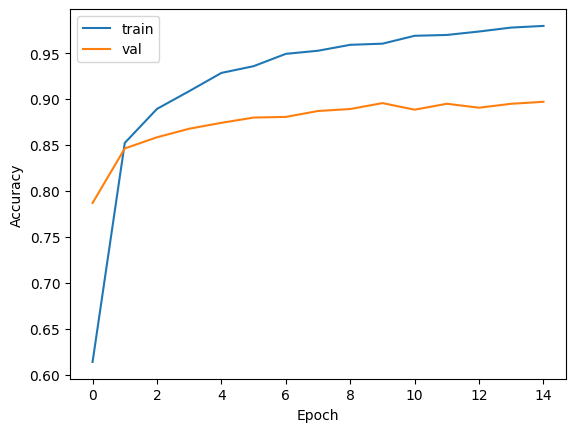

In [13]:
plt.plot(train_acc,label="train")
plt.plot(val_acc,label="val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

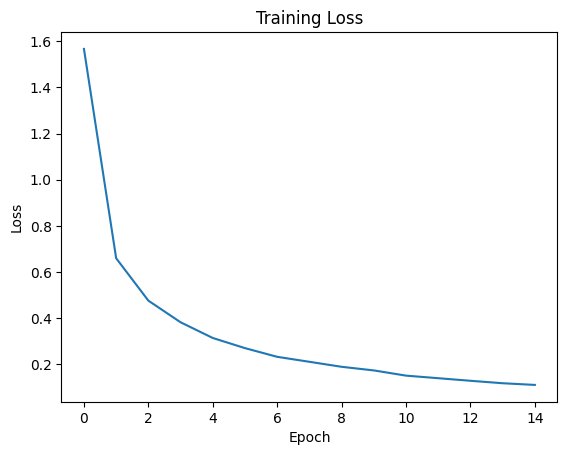

In [14]:
plt.plot(train_loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# **Confusion Matrix**

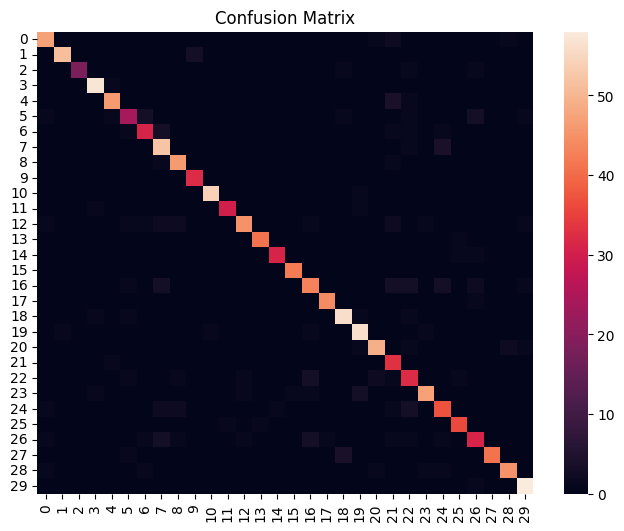

In [15]:
all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm)

plt.title("Confusion Matrix")

plt.show()

# **Feature Embedding (PCA)**

In [16]:
features=[]
labels_list=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        feat = model.forward_features(images)

        feat = feat.mean(dim=(2,3))

        features.append(feat.cpu())
        labels_list.append(labels)

features = torch.cat(features)
labels_list = torch.cat(labels_list)

# **PCA Plot**

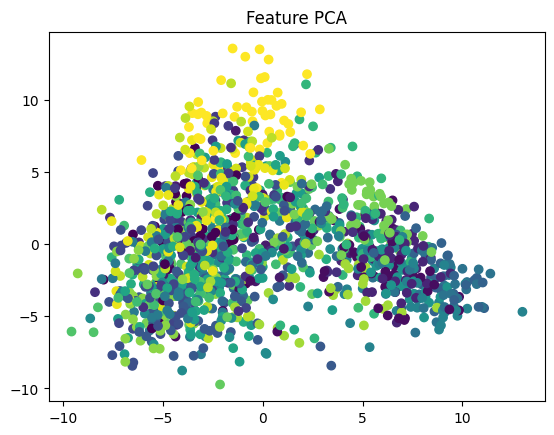

In [17]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(features)

plt.scatter(reduced[:,0],reduced[:,1],c=labels_list)

plt.title("Feature PCA")

plt.show()

# **4.2 — Fine Tuning Strategies**
Helper (count parameters)

In [18]:
def count_trainable(model):

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    print("Trainable %:", trainable/total)

# **Last Block Fine-Tuning (DenseNet)**

# **Selective 20% Unfreeze**

In [19]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False

# unfreeze last dense block
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.get_classifier().parameters():
    param.requires_grad = True

count_trainable(model)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

train_acc_lb, val_acc_lb, loss_acc_lb = train_model(model,train_loader,val_loader)

Trainable %: 0.31337916555350437
Epoch 1: Train=0.446, Val=0.715
Epoch 2: Train=0.798, Val=0.845
Epoch 3: Train=0.872, Val=0.878
Epoch 4: Train=0.918, Val=0.898
Epoch 5: Train=0.944, Val=0.917
Epoch 6: Train=0.958, Val=0.921
Epoch 7: Train=0.977, Val=0.914
Epoch 8: Train=0.984, Val=0.928
Epoch 9: Train=0.986, Val=0.919
Epoch 10: Train=0.990, Val=0.921
Epoch 11: Train=0.990, Val=0.921
Epoch 12: Train=0.994, Val=0.917
Epoch 13: Train=0.995, Val=0.925
Epoch 14: Train=0.994, Val=0.924
Epoch 15: Train=0.996, Val=0.929


In [20]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = False

# unfreeze last two blocks
for param in model.features.denseblock3.parameters():
    param.requires_grad = True

for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.get_classifier().parameters():
    param.requires_grad = True

count_trainable(model)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

train_acc_sel, val_acc_sel, loss_acc_sel = train_model(model,train_loader,val_loader)

Trainable %: 0.7196669361163679
Epoch 1: Train=0.540, Val=0.818
Epoch 2: Train=0.872, Val=0.896
Epoch 3: Train=0.943, Val=0.925
Epoch 4: Train=0.968, Val=0.929
Epoch 5: Train=0.981, Val=0.941
Epoch 6: Train=0.989, Val=0.939
Epoch 7: Train=0.993, Val=0.938
Epoch 8: Train=0.994, Val=0.937
Epoch 9: Train=0.994, Val=0.934
Epoch 10: Train=0.996, Val=0.940
Epoch 11: Train=0.996, Val=0.941
Epoch 12: Train=0.997, Val=0.944
Epoch 13: Train=0.995, Val=0.939
Epoch 14: Train=0.996, Val=0.935
Epoch 15: Train=0.998, Val=0.935


# **Full Fine Tuning**

In [21]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)

for param in model.parameters():
    param.requires_grad = True

count_trainable(model)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

train_acc_full, val_acc_full, loss_acc_full = train_model(model,train_loader,val_loader)

Trainable %: 1.0
Epoch 1: Train=0.592, Val=0.873
Epoch 2: Train=0.909, Val=0.926
Epoch 3: Train=0.962, Val=0.942
Epoch 4: Train=0.982, Val=0.937
Epoch 5: Train=0.991, Val=0.951
Epoch 6: Train=0.994, Val=0.952
Epoch 7: Train=0.994, Val=0.944
Epoch 8: Train=0.995, Val=0.953
Epoch 9: Train=0.996, Val=0.946
Epoch 10: Train=0.996, Val=0.949
Epoch 11: Train=0.993, Val=0.954
Epoch 12: Train=0.993, Val=0.946
Epoch 14: Train=0.997, Val=0.947
Epoch 15: Train=0.997, Val=0.949


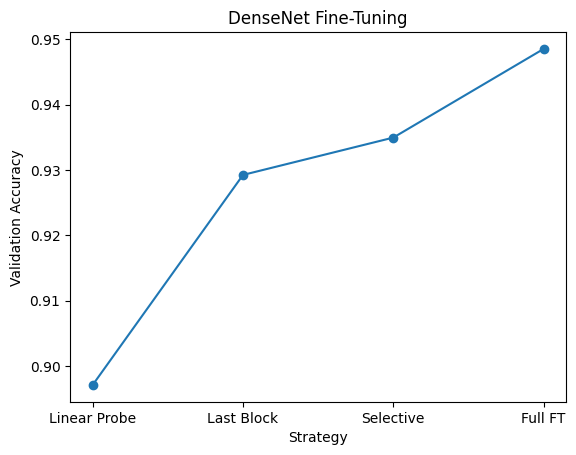

In [22]:
results = [
    val_acc[-1],
    val_acc_lb[-1],
    val_acc_sel[-1],
    val_acc_full[-1]
]

labels = ["Linear Probe","Last Block","Selective","Full FT"]

plt.plot(labels, results, marker="o")

plt.xlabel("Strategy")
plt.ylabel("Validation Accuracy")
plt.title("DenseNet Fine-Tuning")

plt.show()

# **4.3 — Few Shot Learning**
Create subsets

In [23]:
total_size = len(dataset)

size20 = int(0.2 * total_size)
size5 = int(0.05 * total_size)

dataset20,_ = random_split(dataset,[size20,total_size-size20])
dataset5,_ = random_split(dataset,[size5,total_size-size5])

loader20 = DataLoader(dataset20,batch_size=32,shuffle=True)
loader5 = DataLoader(dataset5,batch_size=32,shuffle=True)

# **Train 20%**

In [24]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
train_acc20, val_acc20, loss_acc20 = train_model(model,loader20,val_loader)

Epoch 1: Train=0.231, Val=0.523
Epoch 2: Train=0.768, Val=0.731
Epoch 3: Train=0.899, Val=0.822
Epoch 4: Train=0.961, Val=0.862
Epoch 5: Train=0.983, Val=0.878
Epoch 6: Train=0.986, Val=0.894
Epoch 7: Train=0.996, Val=0.898
Epoch 8: Train=0.996, Val=0.902
Epoch 9: Train=0.997, Val=0.901
Epoch 10: Train=0.992, Val=0.906
Epoch 11: Train=0.999, Val=0.907
Epoch 12: Train=1.000, Val=0.904
Epoch 13: Train=0.999, Val=0.912
Epoch 14: Train=0.999, Val=0.906
Epoch 15: Train=0.998, Val=0.906


# **Train 5%**

In [25]:
model = timm.create_model("densenet121", pretrained=True)
model.reset_classifier(30)
model = model.to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
train_acc5, val_acc5, loss_acc5 = train_model(model,loader5,val_loader)

Epoch 1: Train=0.052, Val=0.067
Epoch 2: Train=0.404, Val=0.208
Epoch 3: Train=0.782, Val=0.318
Epoch 4: Train=0.917, Val=0.407
Epoch 5: Train=0.989, Val=0.475
Epoch 6: Train=0.994, Val=0.541
Epoch 7: Train=0.994, Val=0.585
Epoch 8: Train=0.997, Val=0.631
Epoch 9: Train=1.000, Val=0.666
Epoch 10: Train=0.997, Val=0.687
Epoch 11: Train=1.000, Val=0.705
Epoch 12: Train=1.000, Val=0.711
Epoch 13: Train=1.000, Val=0.721
Epoch 14: Train=1.000, Val=0.724
Epoch 15: Train=1.000, Val=0.720


# **Performance Drop**

In [26]:
acc100 = val_acc[-1]
acc5 = val_acc5[-1]

delta = (acc100 - acc5)/acc100

print("Performance Drop:",delta)

Performance Drop: 0.1976095617529881


# **Accuracy vs Data%**

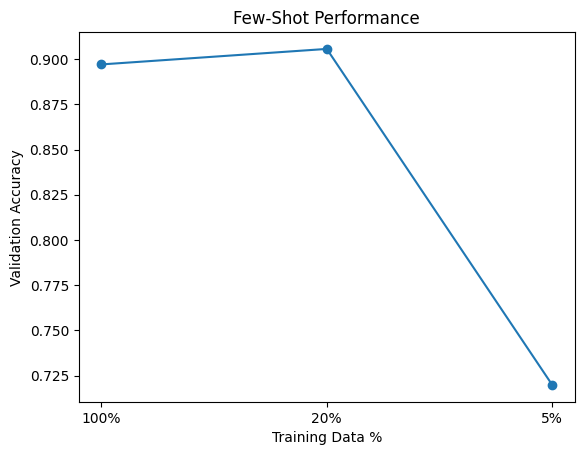

Gap 100%: 0.08255168728467621
Gap 20%: 0.09220718661705019
Gap 5%: 0.28020014295925666


In [27]:
# Accuracy vs Data %
labels = ["100%", "20%", "5%"]
acc_values = [acc100, val_acc20[-1], val_acc5[-1]]

plt.plot(labels, acc_values, marker="o")
plt.xlabel("Training Data %")
plt.ylabel("Validation Accuracy")
plt.title("Few-Shot Performance")
plt.show()

# Overfitting gap
gap_100 = train_acc[-1] - val_acc[-1]
gap_20 = train_acc20[-1] - val_acc20[-1]
gap_5 = train_acc5[-1] - val_acc5[-1]

print("Gap 100%:", gap_100)
print("Gap 20%:", gap_20)
print("Gap 5%:", gap_5)

# **4.4 — Corruption Robustness**
Noise Function

In [28]:
def gaussian_noise(images,sigma):

    noise = torch.randn_like(images)*sigma

    return torch.clamp(images+noise,0,1)

In [29]:
model = timm.create_model("densenet121", pretrained=False)
model.reset_classifier(30)

model.load_state_dict(torch.load("densenet_100.pth"))

model = model.to(device)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): DenseBlock(
      (denselayer1): DenseLayer(
        (norm1): BatchNormAct2d(
          64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
  

# **Corruption Evaluation**

In [30]:
def evaluate(model,loader,noise=None):

    model.eval()

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            if noise:
                images = gaussian_noise(images,noise)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            correct += (preds==labels).sum().item()
            total += labels.size(0)

    return correct/total

# **Run Corruption Tests**

In [31]:
acc_clean = evaluate(model,val_loader)

acc_g05 = evaluate(model,val_loader,0.05)
acc_g1 = evaluate(model,val_loader,0.1)
acc_g2 = evaluate(model,val_loader,0.2)

print(acc_clean,acc_g05,acc_g1,acc_g2)

0.8970693352394568 0.19799857040743388 0.13724088634739098 0.09077912794853467


In [32]:
# Brightness
def brightness_shift(images, factor=1.5):
    return torch.clamp(images * factor, 0, 1)

# Motion blur
import torchvision.transforms as transforms
motion_blur = transforms.GaussianBlur(kernel_size=9)

# Evaluate
def evaluate_full(model, loader, mode=None, sigma=None):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            if mode == "gaussian":
                images = gaussian_noise(images, sigma)
            elif mode == "brightness":
                images = brightness_shift(images)
            elif mode == "motion":
                images = motion_blur(images)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


acc_motion = evaluate_full(model, val_loader, "motion")
acc_bright = evaluate_full(model, val_loader, "brightness")

print("Motion:", acc_motion)
print("Brightness:", acc_bright)

# Corruption Error
ce_g05 = 1 - acc_g05
ce_motion = 1 - acc_motion
ce_bright = 1 - acc_bright

print("CE:", ce_g05, ce_motion, ce_bright)

# Relative Robustness
rr_g05 = acc_g05 / acc_clean
rr_motion = acc_motion / acc_clean
rr_bright = acc_bright / acc_clean

print("RR:", rr_g05, rr_motion, rr_bright)

Motion: 0.6204431736954967
Brightness: 0.1601143674052895
CE: 0.8020014295925662 0.37955682630450327 0.8398856325947105
RR: 0.22071713147410357 0.6916334661354581 0.17848605577689244


# **4.5 Layer Wise Feature Probing**
Feature Extraction

In [33]:
from collections import defaultdict

samples_per_class = 30
class_counts = defaultdict(int)
indices = []

for idx, (_, label) in enumerate(dataset):
    if class_counts[label] < samples_per_class:
        indices.append(idx)
        class_counts[label] += 1

subset = torch.utils.data.Subset(dataset, indices)
subset_loader = DataLoader(subset, batch_size=32)

print("Total samples:", len(subset))   # should be 900

Total samples: 900


In [34]:
early_f = []
mid_f = []
final_f = []
labels_list = []

model.eval()

with torch.no_grad():

    for images, labels in subset_loader:

        images = images.to(device)

        x = model.features.conv0(images)
        x = model.features.norm0(x)
        x = torch.relu(x)
        x = model.features.pool0(x)

        early = torch.flatten(x,1)

        x = model.features.denseblock1(x)
        x = model.features.transition1(x)
        x = model.features.denseblock2(x)

        mid = torch.flatten(x,1)

        x = model.features.transition2(x)
        x = model.features.denseblock3(x)
        x = model.features.transition3(x)
        x = model.features.denseblock4(x)

        final = torch.flatten(x,1)

        early_f.append(early.cpu())
        mid_f.append(mid.cpu())
        final_f.append(final.cpu())
        labels_list.append(labels)

early_f = torch.cat(early_f)
mid_f = torch.cat(mid_f)
final_f = torch.cat(final_f)
labels_list = torch.cat(labels_list)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def probe(features, labels):

    X_train, X_test, y_train, y_test = train_test_split(
        features.numpy(), labels.numpy(), test_size=0.3, random_state=42
    )

    clf = LogisticRegression(max_iter=1000)

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    return accuracy_score(y_test, preds)

In [36]:
acc_early = probe(early_f, labels_list)
acc_mid = probe(mid_f, labels_list)
acc_final = probe(final_f, labels_list)

print("Early Layer Acc:", acc_early)
print("Mid Layer Acc:", acc_mid)
print("Final Layer Acc:", acc_final)

Early Layer Acc: 0.3592592592592593
Mid Layer Acc: 0.6
Final Layer Acc: 0.8518518518518519


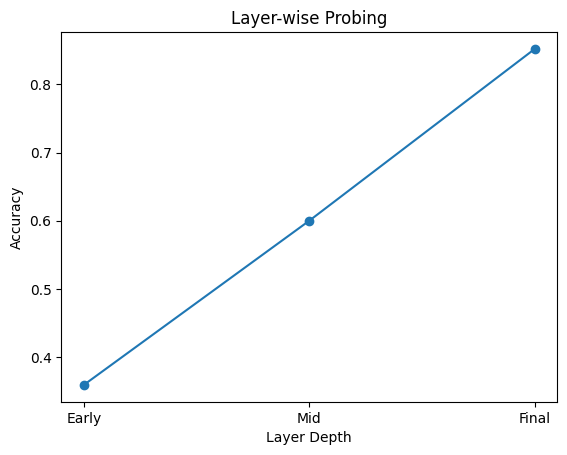

In [37]:
layers = ["Early","Mid","Final"]
accs = [acc_early, acc_mid, acc_final]

plt.plot(layers, accs, marker="o")
plt.xlabel("Layer Depth")
plt.ylabel("Accuracy")
plt.title("Layer-wise Probing")
plt.show()

# **Norms**

In [38]:
import numpy as np

norm_early = np.linalg.norm(early_f.numpy(), axis=1)
norm_mid = np.linalg.norm(mid_f.numpy(), axis=1)
norm_final = np.linalg.norm(final_f.numpy(), axis=1)

print("Early norm mean:", norm_early.mean())
print("Mid norm mean:", norm_mid.mean())
print("Final norm mean:", norm_final.mean())

Early norm mean: 7627.989
Mid norm mean: 1129.837
Final norm mean: 240.18587


# **PCA Visualization**

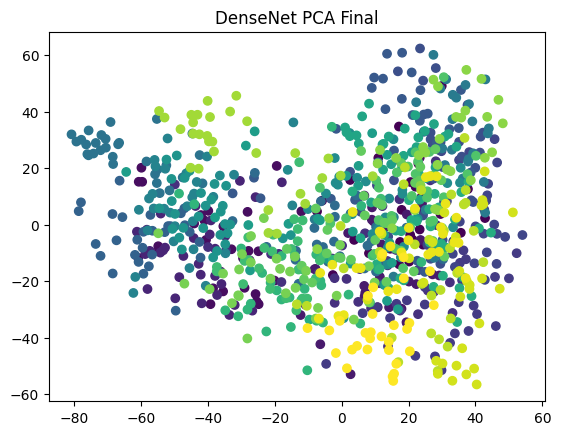

In [39]:
pca = PCA(n_components=2)

early_2d = pca.fit_transform(early_f)
mid_2d = pca.fit_transform(mid_f)
final_2d = pca.fit_transform(final_f)

plt.scatter(final_2d[:,0], final_2d[:,1], c=labels_list)
plt.title("DenseNet PCA Final")
plt.show()